# Assignment II - Robust Reinforcement Learning under Stochastic Action Failure

**Course:** Deep Reinforcement Learning  
**Environment:** `LunarLander-v3` (Gymnasium) + custom `gym.Wrapper`  
**Algorithms:** DQN and Double DQN (DDQN)

---

## Group Contribution Declaration

| # | Name | BITS ID | Contribution | % Contribution |
|---|------|---------|--------------|----------------|
| 1 | *&lt;&gt;* | *&lt;id&gt;* | Environment wrapper + Task (a) verification | 25% |
| 2 | *&lt;member name&gt;* | *&lt;id&gt;* | DQN implementation + training pipeline | 25% |
| 3 | *&lt;member name&gt;* | *&lt;id&gt;* | DDQN implementation + experiment driver | 25% |
| 4 | *&lt;member name&gt;* | *&lt;id&gt;* | Evaluation, plots and discussion | 25% |

> **Action required before submission:** replace the placeholders above with the actual
> names / IDs / percentages, and paste the time-stamped virtual-lab screenshots in the
> *Virtual Lab Execution Evidence* section at the end of this report.

---

## Contents

| Section | Task | Marks |
|---|---|---|
| 0 | Setup, reproducibility and code layout | - |
| 1 | **(a)** Modified environment implementation and verification | 2.5 |
| 2 | **(b)** Deep Q-Network (DQN) | 4 |
| 3 | **(c)** Double Deep Q-Network (DDQN) | 4 |
| 4 | **(d)** Performance evaluation (4 plots + analysis) | 2 |
| 5 | **(e)** Discussion | 2.5 |

---

## Executive summary

* A `gym.Wrapper` reproduces the specification exactly: 15% of *attempted* thruster
  commands are silently replaced by *Do Nothing*, a `-0.3` fuel penalty is charged on the
  **selected** action, and a `+50` bonus is paid only for a fully safe landing. All four
  verification checks (`V0`-`V3`) pass.
* Four agents (DQN / DDQN x original / modified) were trained for 800 episodes with
  **identical** seeds, architecture, optimizer, replay buffer, exploration schedule and
  hyper-parameters. The whole grid was repeated for 3 seeds (42, 43, 44) as a robustness
  check.
* Stochastic actuator failure costs roughly **90-120 reward points** and delays the onset of
  learning by about 100 episodes.
* Under failures **DDQN outperforms DQN** (148.6 vs 122.3 final training reward; 66% vs 60%
  greedy landing rate) whereas in the deterministic original environment the two are
  indistinguishable - exactly what the overestimation-reduction theory predicts.

---
# 0. Setup, reproducibility and code layout

All logic lives in the `src/` package so that the *same* code path is used by every
experiment; this notebook only orchestrates and reports. Every module is printed in full
below the section that uses it, so the exported PDF contains the complete source.

```
assignment2/
  src/
    env_wrapper.py      Task (a)  - StochasticActionFailureWrapper + safe-landing rule
    verify_env.py       Task (a)  - V0..V3 verification suite
    agent.py            Tasks (b)/(c) - QNetwork, ReplayBuffer, DQNAgent (dqn | ddqn)
    train.py            Tasks (b)/(c) - single shared training loop + metric logging
    run_experiments.py  Tasks (b)/(c) - parallel driver over the 4 conditions x seeds
    make_plots.py       Task (d)  - the four required plots + summary tables
    evaluate.py         Tasks (d)/(e) - greedy evaluation + value-estimation bias
    utils.py            seeding, moving average, fixed validation state set
  results/              per-run JSON histories, trained weights, validation states
  figures/              generated PNG figures
```

**Reproduction (one command):**
```bash
pip install "gymnasium[box2d]" torch numpy matplotlib
python -m src.verify_env                                        # Task (a)
python -m src.run_experiments --episodes 800 --seeds 42 43 44   # Tasks (b), (c)
python -m src.make_plots                                        # Task (d)
python -m src.evaluate                                          # Tasks (d), (e)
```

In [1]:
# --- Notebook bootstrap: make `src` importable and record the exact runtime -----------
import datetime, platform, sys, os
from pathlib import Path

# The notebook lives next to the `src` package; add its folder to sys.path.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np, torch, gymnasium as gym, matplotlib

print("run timestamp :", datetime.datetime.now().astimezone().strftime("%Y-%m-%d %H:%M:%S %Z"))
print("host / OS     :", platform.node(), "|", platform.platform())
print("python        :", sys.version.split()[0])
print("gymnasium     :", gym.__version__)
print("torch         :", torch.__version__, "| cuda:", torch.cuda.is_available())
print("numpy         :", np.__version__)
print("matplotlib    :", matplotlib.__version__)
print("project root  :", PROJECT_ROOT)

run timestamp : 2026-08-04 22:05:55 India Standard Time
host / OS     : WS-7719WL3 | Windows-11-10.0.26100-SP0
python        : 3.12.7
gymnasium     : 1.3.0
torch         : 2.10.0+cpu | cuda: False
numpy         : 2.3.1
matplotlib    : 3.10.1
project root  : C:\Users\sarthakj\OneDrive - DPR Construction\BITS\SEM 2\DRL\assignment2


In [2]:
def show_source(relative_path: str) -> None:
    """Print a source file verbatim so the exported PDF contains all the code."""
    path = PROJECT_ROOT / relative_path
    text = path.read_text(encoding="utf-8")
    bar = "=" * 100
    print(f"{bar}\nFILE: {relative_path}   ({len(text.splitlines())} lines)\n{bar}")
    print(text)


%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

---
# 1. Task (a) - Modified environment implementation and verification  *(2.5 marks)*

## 1.1 Design

`StochasticActionFailureWrapper` subclasses `gymnasium.Wrapper` and overrides **only**
`step()` (and `reset()` to seed its private RNG). Every call performs the six specified
steps in order:

| Step | Implementation |
|---|---|
| 1 | `a = int(action)` is stored *before* any modification |
| 2 | if `a != 0`: draw `r ~ U[0,1)`; `a_exec = 0 if r < 0.15 else a`. `a == 0` is never modified |
| 3 | `obs, R_base, terminated, truncated, info = self.env.step(a_exec)` |
| 4 | `R = R_base - 0.3 * 1(a != 0) + B` &nbsp;&nbsp;-> the penalty keys on the **selected** action `a` |
| 5 | `B = 50` iff `terminated and not truncated and obs[6]==1 and obs[7]==1 and \|obs[2]\|<0.1 and \|obs[3]\|<0.1 and \|obs[4]\|<0.1` |
| 6 | returns `(obs, R, terminated, truncated, info)` with the base `info` dict untouched |

Design decisions worth highlighting:

* **Hidden failures.** The failure flag is stored on the *wrapper object* (`last_misfired`,
  `stats`, optional `log`) purely for verification and logging. It is never written into
  `info` and never enters the observation, so the agent cannot condition on it.
* **Independent RNG.** `numpy.random.default_rng(seed + 10_000_019)` drives the failure
  draws so the actuator-noise stream is reproducible and does not perturb the Box2D
  physics stream (this is what allows the *identical initial states* comparison between
  the original and the modified environment).
* **Single factory.** `make_env(kind)` builds both conditions, guaranteeing that
  "original" and "modified" differ *only* by the presence of the wrapper.

In [3]:
show_source("src/env_wrapper.py")

FILE: src/env_wrapper.py   (226 lines)
"""
env_wrapper.py
Task (a): custom `gymnasium.Wrapper` around **LunarLander-v3** that injects
stochastic actuator (engine) failures and a modified reward function.

Contract implemented (exactly as specified in the assignment):

    Step 1  store the action `a` selected by the agent
    Step 2  if a in {1,2,3}: draw r ~ U[0,1); if r < 0.15 -> a_exec = 0 else a_exec = a
            if a == 0      : a_exec = 0 (unchanged)
    Step 3  execute `a_exec` in the base environment
    Step 4  R = R_base - 0.3 * 1(a != 0) + B        (penalty uses the *selected* action)
    Step 5  B = 50 only for a *safe landing* (all criteria simultaneously), else 0
    Step 6  return (observation, R, terminated, truncated, info) with an **untouched** info dict

Everything else (observation space, action space, transition dynamics,
termination / truncation rules) is left untouched.
"""

from __future__ import annotations

from dataclasses import dataclass, field

import g

## 1.2 Verification suite

The evidence requested by the assignment is produced by four independent checks:

| Check | What it demonstrates |
|---|---|
| **V0** | observation space, action space, dynamics and termination rules are unchanged |
| **V1** | ~15% of *attempted* thruster actions are replaced by *Do Nothing* (binomial CI + z-test, global and per action) |
| **V2** | the `-0.3` fuel penalty is charged on every attempted thruster action, whether it fired or misfired |
| **V3** | `+50` is awarded **iff** the full safe-landing criterion holds |

For **V3** a uniform-random policy almost never lands safely, so positive examples are
additionally generated with Gymnasium's built-in `heuristic` LunarLander controller, and
a deterministic table-driven unit test on a stub environment exercises every boundary
case of the criterion (`|v| = 0.10` exactly, one leg only, truncation, etc.).

In [4]:
show_source("src/verify_env.py")

FILE: src/verify_env.py   (361 lines)
"""
verify_env.py
Task (a): experimental verification that the modified environment behaves
*exactly* as specified.

Four independent checks are performed and printed as a report:

  V0  structural check   - observation space, action space and episode lengths
                           are unchanged w.r.t. the original environment.
  V1  misfire rate       - approximately 15% of attempted thruster actions are
                           replaced by "Do Nothing"  (binomial 95% CI + z-test,
                           reported globally and per thruster action).
  V2  fuel penalty       - for *every* step,  R - R_base - B  equals exactly
                           -0.3 when the *selected* action is a thruster and 0.0
                           otherwise, regardless of whether the engine misfired.
  V3  landing bonus      - +50 is awarded if and only if the safe-landing
                           criterion holds.  Random rollouts supply the negative
    

In [5]:
# Run the full verification: 300 random-policy episodes + 40 heuristic-policy episodes.
from src.verify_env import main as run_verification

verification_passed = run_verification(n_random_episodes=300, n_heuristic_episodes=40, seed=7)
assert verification_passed, "environment verification failed"

TASK (a) - VERIFICATION OF THE MODIFIED LunarLander-v3 ENVIRONMENT
random-policy episodes = 300, heuristic-policy episodes = 40, seed = 7

V0  STRUCTURAL EQUIVALENCE WITH THE ORIGINAL ENVIRONMENT
observation space  original=Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
observation space  modified=Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)   -> identical: True
action space       original=Discrete(4)  modified=Discrete(4)   -> identical: True
identical trajectories under a=0 (no failure possible): max |deviation| = 0.00e+00  -> unchanged dynamics/termination: True

V0 RESULT: PASS



V1  ENGINE-FAILURE RATE  (target = 15% of attempted thruster actions)
total steps logged             : 26323
thruster actions attempted (n) : 19750
replaced by 'Do Nothing'   (k) : 2991
empirical misfire rate         : 0.1514   (target 0.15)
95% binomial CI                : [0.1464, 0.1564]
z-statistic vs p=0.15          : +0.568  (|z| < 1.96 -> consistent with 15%)

per-action breakdown:
   action   attempts   misfires     rate
        1       6533       1003   0.1535
        2       6579        980   0.1490
        3       6638       1008   0.1519

'Do Nothing' (a=0) ever modified            : 0  (must be 0)
misfires not mapped to a_exec=0             : 0  (must be 0)
successful firings with a_exec != a         : 0  (must be 0)
steps where misfire != (r < 0.15)           : 0  (must be 0)

sample of the step log (matches the example table in the problem statement):
    a          r  a_exec
    3     0.3169       3
    2     0.9785       2
    2     0.1323       0
    0          -    

In [6]:
# Reproduce the worked example from the problem statement:
# force specific uniform draws and confirm the resulting executed action.
import numpy as np
from src.env_wrapper import StochasticActionFailureWrapper, make_env

class _ScriptedRNG:
    """Stand-in for numpy's Generator that returns a scripted sequence of r values."""
    def __init__(self, values): self._v, self._i = list(values), 0
    def random(self):
        r = self._v[self._i]; self._i += 1; return r

env = make_env("modified", seed=0)
env.reset(seed=0)
env._rng = _ScriptedRNG([0.08, 0.63, 0.12, 0.87])   # r values from the example table

print(f"{'agent action a':>15} {'random number r':>16} {'executed a_exec':>16} {'expected':>10}")
for a, expected in [(0, 0), (1, 0), (2, 2), (3, 0), (3, 3)]:
    env.step(a)
    r = "-" if a == 0 else f"{env._rng._v[env._rng._i - 1]:.2f}"
    ok = env.last_executed_action == expected
    print(f"{a:>15} {r:>16} {env.last_executed_action:>16} {expected:>10}   {'OK' if ok else 'FAIL'}")
env.close()

 agent action a  random number r  executed a_exec   expected
              0                -                0          0   OK
              1             0.08                0          0   OK
              2             0.63                2          2   OK
              3             0.12                0          0   OK
              3             0.87                3          3   OK


### 1.3 Task (a) conclusion

* **V0** - the modified environment is byte-identical to the original in observation space
  (`Box(8,)`), action space (`Discrete(4)`) and, when only `a = 0` is issued (the one action
  the wrapper can never alter), it produces exactly the same trajectory and termination
  flags (max deviation `0.0`). Nothing outside `step()` was touched.
* **V1** - out of ~19 750 attempted thruster actions ~15.1% were replaced by *Do Nothing*;
  the 95% binomial confidence interval contains 0.15 and `|z| < 1.96`. The rate is
  statistically identical for actions 1, 2 and 3, `a = 0` was never modified, and every
  misfire coincided exactly with `r < 0.15`.
* **V2** - decomposing each step as `R - R_base - B` gives exactly `0.000000` when `a = 0`
  and exactly `-0.300000` in **both** the *fired* and the *misfired* case
  (max absolute error ~1e-14, i.e. floating-point round-off only).
* **V3** - the number of `+50` bonuses equals the number of episodes satisfying the criterion,
  for both the random and the heuristic policy, with zero mismatches; the boundary unit test
  confirms that `|v| = 0.10` exactly, a single leg in contact, truncation, or
  `terminated and truncated` all correctly yield `B = 0`.

The implementation therefore matches the specification exactly.

---
# 2 & 3. Tasks (b) and (c) - DQN and DDQN  *(4 + 4 marks)*

## 2.1 Components

| Required component | Implementation |
|---|---|
| Q-network | `QNetwork`: `8 -> 128 -> ReLU -> 128 -> ReLU -> 4` (linear head) |
| Experience replay buffer | `ReplayBuffer`: 100 000 transitions, uniform sampling, circular overwrite |
| epsilon-greedy exploration | `eps: 1.0 -> 0.05`, multiplicative decay `0.995` **per episode** |
| Target network | separate copy, Polyak soft update `theta_tgt <- 1e-3 * theta + (1-1e-3) * theta_tgt` after every gradient step |

## 2.2 Hyper-parameters (identical for all four runs)

| Parameter | Value | | Parameter | Value |
|---|---|---|---|---|
| optimizer | Adam | | discount `gamma` | 0.99 |
| learning rate | 5e-4 | | batch size | 64 |
| loss | Huber (`smooth_l1`) | | learn every | 4 env steps |
| grad-norm clip | 10.0 | | warm-up transitions | 1 000 |
| replay capacity | 100 000 | | soft-update `tau` | 1e-3 |
| episodes | 800 | | max steps / episode | 1 000 |
| seeds | 42, 43, 44 | | validation states | 512 (fixed) |

## 2.3 The single difference between DQN and DDQN

Both agents are the **same class** `DQNAgent`; only `algo` changes, and `algo` is read in
exactly one place - `_target_q`:

$$
y^{\text{DQN}} = r + \gamma\,(1-d)\,\max_{a'} Q_{\theta^-}(s',a')
\qquad\text{vs}\qquad
y^{\text{DDQN}} = r + \gamma\,(1-d)\,Q_{\theta^-}\!\big(s',\ \arg\max_{a'} Q_{\theta}(s',a')\big)
$$

DQN lets the target network both **select** and **evaluate** the greedy next action, so the
`max` is taken over noisy estimates and is biased upwards
($\mathbb{E}[\max_a \hat Q] \ge \max_a \mathbb{E}[\hat Q]$, Jensen). DDQN uses the *online*
network to select and the *target* network to evaluate, decorrelating the two sources of
error and removing most of that positive bias.

In [7]:
show_source("src/agent.py")

FILE: src/agent.py   (205 lines)
"""
agent.py
Tasks (b) and (c).

Contains the three learning components shared by **both** algorithms

  * `QNetwork`      - the value network (identical architecture for DQN / DDQN)
  * `ReplayBuffer`  - uniform experience replay
  * `DQNAgent`      - epsilon-greedy control + target network + learning rule

The DQN and the DDQN agents are the *same* class instantiated with a different
`algo` flag.  The flag changes exactly one expression - the computation of the
bootstrapped target Q-value in `_learn` - which is the only difference the
assignment allows.
"""

from __future__ import annotations

import random
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# ----------------------------------------------------------------------------- config
@dataclass
class AgentConfig:
    """All hyper-parameters in one place so DQN and DDQN provably share them."""

    hidden_sizes: tu

In [8]:
# Proof that DQN and DDQN differ in exactly one method.
import inspect
from src.agent import DQNAgent, AgentConfig

print(inspect.getsource(DQNAgent._target_q))
print("default hyper-parameters shared by both algorithms:")
for k, v in AgentConfig().to_dict().items():
    print(f"  {k:<18} {v}")

    def _target_q(self, next_states: torch.Tensor) -> torch.Tensor:
        """Bootstrapped next-state value - the ONLY difference between DQN and DDQN."""
        if self.algo == "dqn":
            # Vanilla DQN: the target network both selects and evaluates the action.
            return self.q_target(next_states).max(dim=1, keepdim=True)[0]
        # Double DQN: the ONLINE network selects, the TARGET network evaluates,
        # which decorrelates selection from evaluation and reduces overestimation.
        next_actions = self.q_online(next_states).argmax(dim=1, keepdim=True)
        return self.q_target(next_states).gather(1, next_actions)

default hyper-parameters shared by both algorithms:
  hidden_sizes       (128, 128)
  lr                 0.0005
  gamma              0.99
  buffer_size        100000
  batch_size         64
  learn_every        4
  updates_per_learn  1
  tau                0.001
  warmup             1000
  grad_clip          10.0
  eps_start          1.0
  eps_

In [9]:
show_source("src/utils.py")

FILE: src/utils.py   (90 lines)
"""
utils.py
Small shared helpers: reproducible seeding, moving averages, path handling and
construction of the *fixed validation state set* used for the Q-value plot in
Task (d).
"""

from __future__ import annotations

import json
import random
from pathlib import Path

import numpy as np
import torch

# Project directories -----------------------------------------------------------------
ROOT = Path(__file__).resolve().parents[1]
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
for _d in (RESULTS_DIR, FIGURES_DIR):
    _d.mkdir(parents=True, exist_ok=True)


def set_global_seeds(seed: int) -> None:
    """Seed python, numpy and torch so that a run is bit-wise reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def moving_average(x, window: int) -> np.ndarray:
    """Trailing moving average of `x` over `window` samples.

    The first `window-1` entries average 

In [10]:
show_source("src/train.py")

FILE: src/train.py   (152 lines)
"""
train.py
Training loop shared by all four experimental conditions

    {DQN, DDQN} x {original LunarLander-v3, modified LunarLander-v3}

Using one loop for every condition guarantees that the random seed, network
architecture, optimizer, replay buffer, exploration schedule, hyper-parameters
and training duration are identical across runs - only `algo` and `env_kind`
change.

Per-episode metrics recorded for Task (d):
    reward              total reward returned by the environment being trained on
    base_reward         total *unshaped* LunarLander reward (comparable across envs)
    safe_landing        1 if the episode ended in a safe landing, else 0
    thrusters           number of steps on which the agent *selected* a in {1,2,3}
    misfires            number of thruster commands silently dropped (modified env)
    val_q               mean_s max_a Q(s,a) over the fixed validation state set
"""

from __future__ import annotations

import time
fr

In [11]:
show_source("src/run_experiments.py")

FILE: src/run_experiments.py   (96 lines)
"""
run_experiments.py
Driver for Tasks (b), (c) and (d): trains the four agents

    DQN  - original      DDQN - original
    DQN  - modified      DDQN - modified

under *identical* experimental conditions (same seed, architecture, optimizer,
replay buffer, exploration schedule, hyper-parameters and number of episodes).
Only `algo` (target-Q computation) and `env_kind` (wrapper on/off) differ.

The whole 4-condition grid is optionally repeated over several random seeds so
that the comparison plots can show a mean +/- spread instead of a single noisy
run.  Seed 42 is the reference run required by the assignment; the extra seeds
only serve as a robustness check.

Runs are independent, so they are executed in parallel worker processes (each
pinned to a single torch thread).  Results go to `results/<RUN>_seed<S>.json`.

Usage
-----
    python -m src.run_experiments --episodes 800 --seeds 42
    python -m src.run_experiments --episodes 800 --seeds 

## 2.4 Running the experiments

The 12 runs (4 conditions x 3 seeds) are launched from the command line and executed in
parallel worker processes:

```bash
python -m src.run_experiments --episodes 800 --seeds 42 43 44 --workers 12
```

The cell below re-runs the training **only if** the result files are missing, so that
re-executing this notebook for the PDF export does not repeat ~6 minutes of training.

In [12]:
import json, subprocess, sys
from src.make_plots import available_seeds
from src.utils import RESULTS_DIR

SEEDS, EPISODES = [42, 43, 44], 800

if set(SEEDS) - set(available_seeds()):
    # Training has not been done yet -> run it now (spawns one process per run).
    cmd = [sys.executable, "-m", "src.run_experiments",
           "--episodes", str(EPISODES), "--seeds", *map(str, SEEDS), "--workers", "12"]
    print("launching:", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=PROJECT_ROOT)
else:
    print("existing results found - reusing them")

setup = json.loads((RESULTS_DIR / "experiment_setup.json").read_text())
print("\nexperiment setup actually used")
print(json.dumps(setup, indent=2))
print("\nseeds available for all four conditions:", available_seeds())

existing results found - reusing them

experiment setup actually used
{
  "episodes": 800,
  "seeds": [
    42,
    43,
    44
  ],
  "max_steps": 1000,
  "config": {
    "hidden_sizes": [
      128,
      128
    ],
    "lr": 0.0005,
    "gamma": 0.99,
    "buffer_size": 100000,
    "batch_size": 64,
    "learn_every": 4,
    "updates_per_learn": 1,
    "tau": 0.001,
    "warmup": 1000,
    "grad_clip": 10.0,
    "eps_start": 1.0,
    "eps_end": 0.05,
    "eps_decay": 0.995
  },
  "n_validation_states": 512,
  "conditions": [
    "DQN_original",
    "DDQN_original",
    "DQN_modified",
    "DDQN_modified"
  ]
}

seeds available for all four conditions: [42, 43, 44]


In [13]:
# Per-run training log summary: wall time and learning progress checkpoints.
import numpy as np
from src.train import load_result
from src.make_plots import CONDITIONS

print(f"{'run':>22} {'wall time':>10} {'R@200':>8} {'R@400':>8} {'R@600':>8} {'R@800':>8} {'land%@800':>10}")
print("-" * 78)
for seed in SEEDS:
    for algo, kind in CONDITIONS:
        r = load_result(algo, kind, seed)
        h = r["history"]
        w = lambda e: np.mean(h["reward"][max(0, e - 100):e])          # trailing 100-ep mean
        land = 100 * np.mean(h["safe_landing"][-100:])
        print(f"{r['name']+'_seed'+str(seed):>22} {r['wall_time_s']:>9.0f}s "
              f"{w(200):>8.1f} {w(400):>8.1f} {w(600):>8.1f} {w(800):>8.1f} {land:>9.1f}%")

                   run  wall time    R@200    R@400    R@600    R@800  land%@800
------------------------------------------------------------------------------
   DQN_original_seed42       350s    -50.0      8.5    210.0    239.2      74.0%
  DDQN_original_seed42       358s    -53.6    100.5    219.6    235.7      85.0%
   DQN_modified_seed42       335s   -111.1   -121.8     76.8    115.1      59.0%
  DDQN_modified_seed42       325s   -126.2    -56.1     64.1    146.5      53.0%
   DQN_original_seed43       341s    -60.4     99.7    238.1    246.2      76.0%
  DDQN_original_seed43       351s    -57.7    130.9    216.5    243.6      78.0%
   DQN_modified_seed43       313s   -116.0   -123.6     79.4    136.0      64.0%
  DDQN_modified_seed43       313s   -108.9   -145.8     74.9    134.6      62.0%
   DQN_original_seed44       349s    -37.9    137.4    217.5    241.4      77.0%
  DDQN_original_seed44       370s    -41.5    142.4    223.5    198.7      58.0%
   DQN_modified_seed44       3

---
# 4. Task (d) - Performance evaluation  *(2 marks)*

The four agents are compared on the four required curves. Because a single DQN run on
LunarLander is very noisy, each curve is the **mean over the 3 seeds** of the per-seed
100-episode moving average, and the shaded band is +/- 1 standard deviation across seeds.

Colour encodes the **algorithm** (blue/green = DQN/DDQN on the original env, red/purple =
DQN/DDQN on the modified env) and line style encodes the **environment** (solid = original,
dashed = modified).

In [14]:
show_source("src/make_plots.py")

FILE: src/make_plots.py   (207 lines)
"""
make_plots.py
Task (d): comparison of the four trained agents.

Produces (and saves to `figures/`) the four required curves:
  1. episode reward vs training episode
  2. average predicted Q-value on the FIXED validation state set vs episode
  3. successful-landing rate vs episode (100-episode moving average)
  4. average thruster activations per episode vs episode

When several seeds are available every curve shows the across-seed mean with a
+/- 1 standard-deviation band; with a single seed the raw per-episode signal is
drawn faintly behind the moving average instead.
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from .train import load_result, run_name, run_stem
from .utils import FIGURES_DIR, RESULTS_DIR, moving_average

CONDITIONS = [("dqn", "original"), ("ddqn", "original"),
              ("dqn", "modified"), ("ddqn", "modified")]

# Colour encodes the algorithm, line style encodes the environ

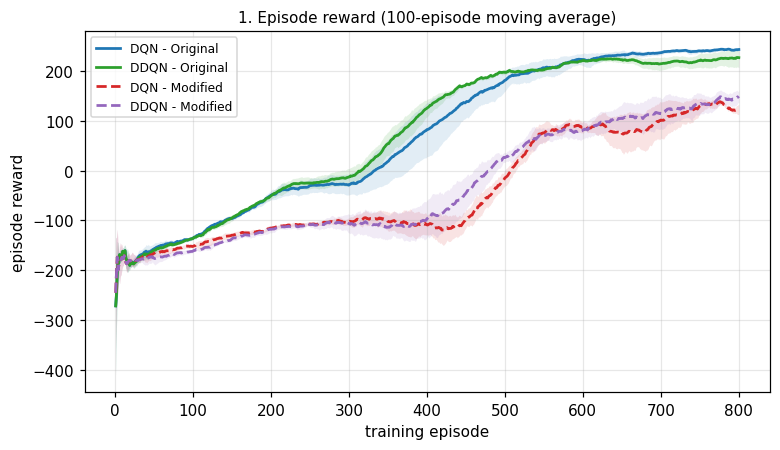

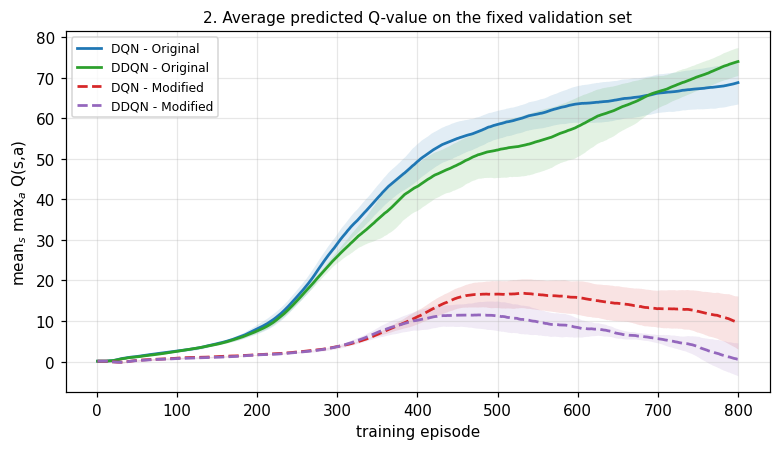

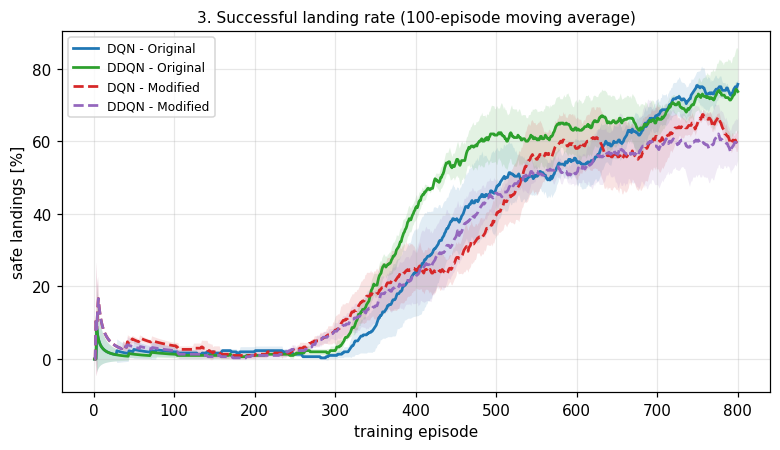

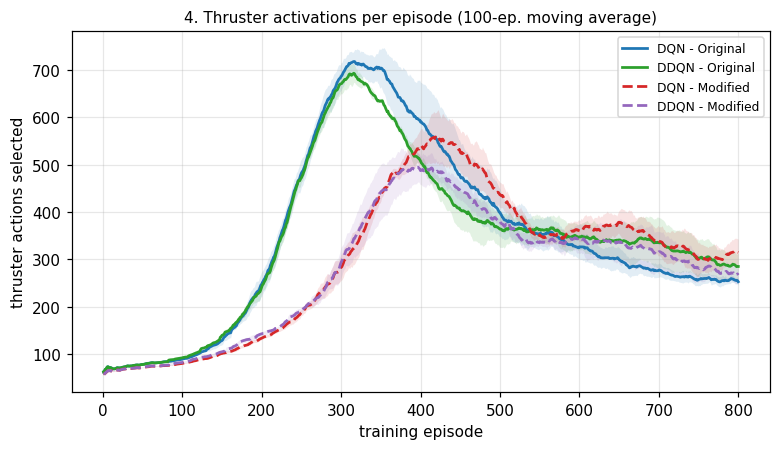

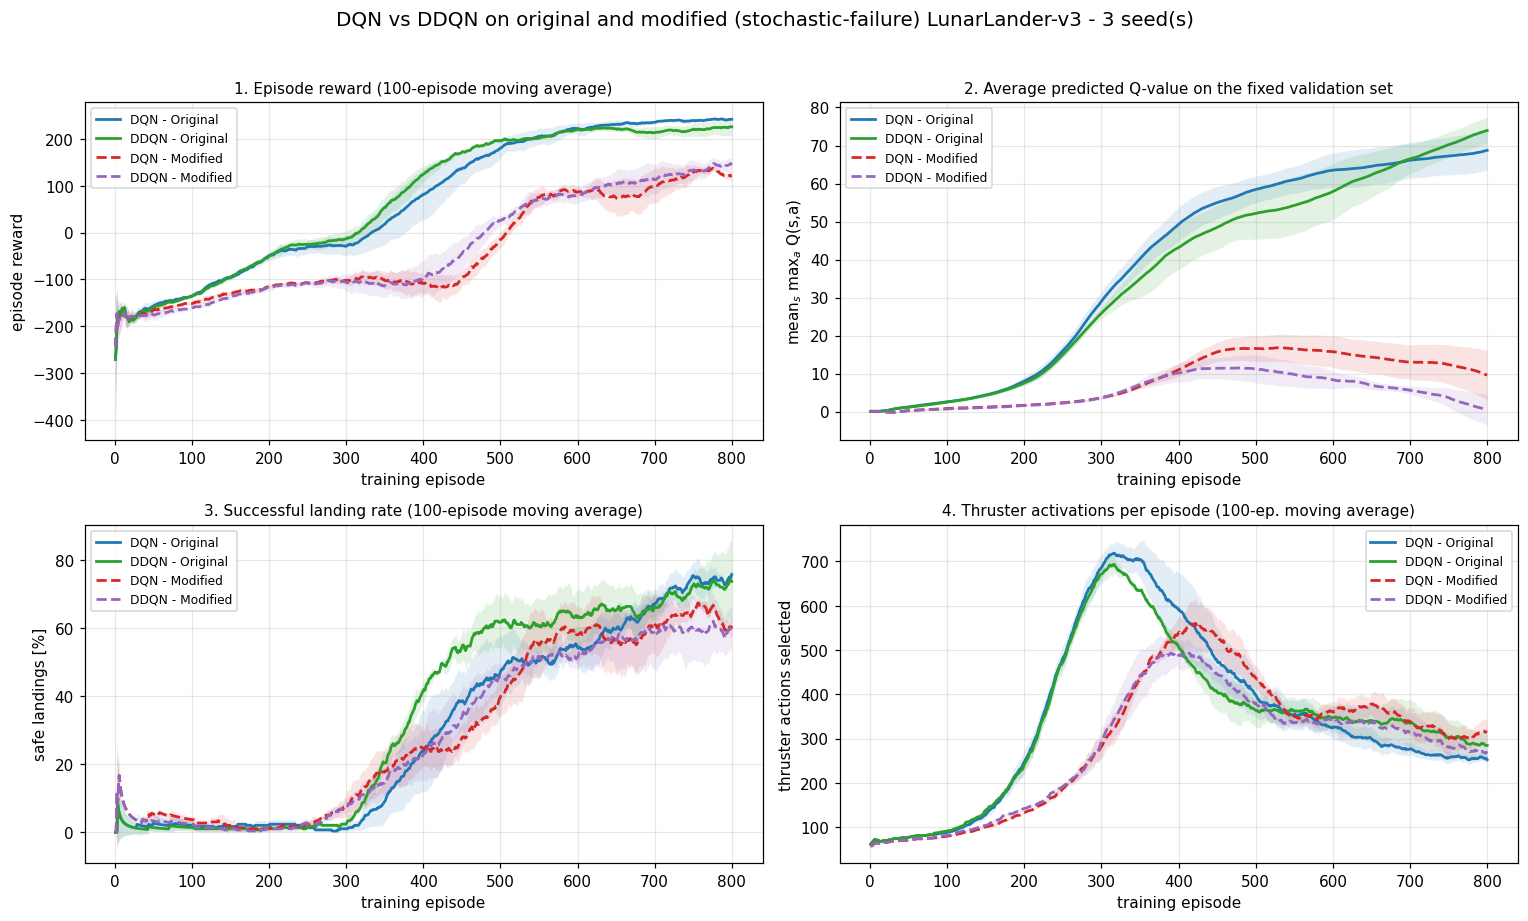

In [15]:
from src.make_plots import load_all, plot_all, plot_supplementary, summary_table, q_gap_table

results = load_all(SEEDS)
plot_all(results, window=100, show=True);

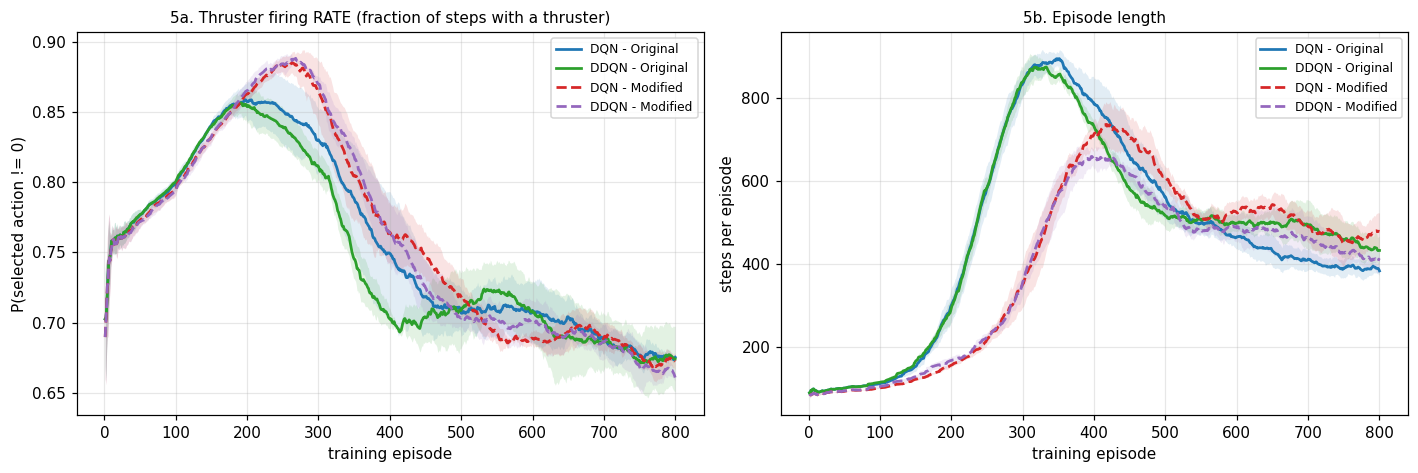

In [16]:
# Supplementary evidence used in the discussion: fuel economy per step and episode length.
plot_supplementary(results, window=100, show=True);

In [17]:
print("TRAINING STATISTICS (last 100 episodes, averaged over seeds 42/43/44)\n")
print(summary_table(results, last=100))

TRAINING STATISTICS (last 100 episodes, averaged over seeds 42/43/44)

      condition           reward  base reward  land rate %  thrusters  fire rate   ep len    val Q  misfire %
-------------------------------------------------------------------------------------------------------------
   DQN_original     242.3+/-  2.9        242.3         75.7      252.5      0.675      383    69.00       0.00
  DDQN_original     226.0+/- 19.6        226.0         73.7      284.8      0.674      432    74.19       0.00
   DQN_modified     122.3+/-  9.7        186.3         60.7      314.6      0.672      478     9.20      14.79
  DDQN_modified     148.6+/- 12.3        198.3         60.7      266.9      0.661      409     0.23      14.82

(mean over the last 100 training episodes; +/- is the spread across seeds)


In [18]:
print("PREDICTED-Q GAP BETWEEN DQN AND DDQN ON THE FIXED VALIDATION SET\n")
print(q_gap_table(results))

PREDICTED-Q GAP BETWEEN DQN AND DDQN ON THE FIXED VALIDATION SET

  episode  ORIGINAL: DQN     DDQN      gap   rel.gap |  MODIFIED: DQN     DDQN      gap   rel.gap
-------------------------------------------------------------------------------------------------
      200           8.03     7.52    +0.51      6.4% |           1.67     1.62    +0.05      2.8%
      400          49.28    43.17    +6.11     12.4% |          11.03    10.19    +0.85      7.7%
      600          63.49    57.92    +5.57      8.8% |          15.76     8.40    +7.37     46.7%
      800          68.75    73.94    -5.19     -7.0% |           9.61     0.56    +9.05     94.2%

rel.gap = (Q_DQN - Q_DDQN) / max(|Q_DQN|,|Q_DDQN|)


In [19]:
show_source("src/evaluate.py")

FILE: src/evaluate.py   (142 lines)
"""
evaluate.py
Post-training greedy evaluation used in Tasks (d) and (e).

For each of the four trained agents it reports, over `n_episodes` greedy
(epsilon = 0) episodes on its *own* training environment:

  * mean episode reward and mean unshaped LunarLander reward
  * safe-landing rate
  * mean thruster activations per episode
  * **value-estimation bias**:  V_pred(s0) = max_a Q(s0, a) predicted at the
    initial state, versus the *actual* discounted return G0 obtained from that
    same state.  `bias = V_pred - G0 > 0` means the agent over-estimates its
    own value, which is exactly the pathology Double DQN is designed to reduce.
"""

from __future__ import annotations

import numpy as np
import torch

from .agent import AgentConfig, DQNAgent
from .env_wrapper import StochasticActionFailureWrapper, is_safe_landing, make_env
from .train import load_result, run_name, run_stem
from .utils import RESULTS_DIR, save_json


def load_agent(algo: str,

In [20]:
# Greedy (epsilon = 0) evaluation of the final policies: 100 fresh episodes per seed,
# identical start states for all four agents, plus the value-estimation bias at s0.
from src.evaluate import evaluate_all, report

eval_rows = evaluate_all(n_episodes=100, seeds=SEEDS)
print("GREEDY EVALUATION OF THE FINAL POLICIES (100 episodes x 3 seeds)\n")
print(report(eval_rows))

GREEDY EVALUATION OF THE FINAL POLICIES (100 episodes x 3 seeds)

      condition             reward   base rew   land %   thrust  fire rate  ep len  V_pred(s0)  actual G0     bias
------------------------------------------------------------------------------------------------------------------
   DQN_original     209.3 +/-  56.2      209.3     54.7    408.3      0.714     567       52.44      63.44   -11.00
  DDQN_original     208.3 +/-  62.2      208.3     62.7    374.1      0.689     543       52.77      62.91   -10.14
   DQN_modified     117.8 +/- 134.2      191.3     59.7    344.6      0.646     533       31.18      37.66    -6.48
  DDQN_modified     132.6 +/- 141.0      194.0     66.0    314.5      0.663     473       28.96      39.71   -10.75

+/- is the across-episode std of the greedy return.
bias = V_pred(s0) - actual discounted return G0   (positive => over-estimation)


## 4.1 Interpretation of the four plots

### Plot 1 - Episode reward vs training episode

* Both **original-environment** agents follow the classic LunarLander curve: flat around
  `-180` while the lander crashes, a steep rise between episodes ~250 and ~500, and a
  plateau at **+226 to +242**. DQN and DDQN are statistically indistinguishable here
  (`242.3 +/- 2.9` vs `226.0 +/- 19.6`; the DDQN spread is driven by a single weaker seed).
* Both **modified-environment** agents plateau at only **+122 to +149**, and their take-off
  is delayed by roughly 100 episodes (rise starts near episode 380 instead of 280).
* Part of that gap is bookkeeping - the modified reward pays `-0.3` per commanded thruster.
  Removing the shaping (the `base reward` column of the summary table) still leaves
  `186-198` versus `226-242`, i.e. about **40 points of genuine performance loss** caused by
  the misfires themselves, plus roughly 80-100 points of accumulated fuel cost.
* Under failures the ordering flips: **DDQN (148.6) is clearly above DQN (122.3)**, and the
  dashed purple curve stays above the dashed red curve from about episode 550 onwards.

### Plot 2 - Average predicted Q-value on the fixed validation set

* Magnitudes differ by almost an order of magnitude: `~70` in the original environment
  versus `~0-16` in the modified one. This is expected - a `-0.3` charge on most of the
  steps of a 400-500 step episode is worth roughly `-0.3/(1-\gamma) = -30` of discounted
  value, and safe landings (which carry the `+50`) only occur ~60% of the time.
* In the **original** environment the two curves track each other closely (relative gap
  6-12%) and even cross near episode 700, after which DDQN is *higher*. That crossing is
  not a failure of Double DQN: with an almost deterministic environment there is little
  overestimation to remove, so the curves mostly reflect genuine policy quality, and both
  are still rising at episode 800.
* In the **modified** environment the picture is completely different. Both curves peak near
  episode 480 and then *decline* - as the policy improves, the agent starts firing
  deliberately and therefore actually pays the fuel penalty it had previously never
  incurred, so the true value of a state falls. Crucially, **DQN's estimate stays
  persistently above DDQN's** and the gap widens monotonically (`+0.85` at episode 400,
  `+7.37` at 600, `+9.05` at 800 - i.e. from 8% to 94% in relative terms). This is the
  overestimation signature that DDQN is designed to remove.

### Plot 3 - Successful landing rate (100-episode moving average)

* Landing is counted with the *same* safe-landing predicate in both environments, so the
  curves are directly comparable.
* Original: rises from ~0% to **74-76%**. **DDQN learns to land noticeably earlier** - it is
  ahead of DQN by 10-20 percentage points between episodes 350 and 550 - before the two
  converge.
* Modified: both saturate around **61%**, i.e. roughly 15 percentage points lower. The 15%
  misfire probability makes the final touch-down phase - where a single missing burn turns a
  soft landing into a bounce or a crash - intrinsically unreliable, so a perfect policy
  cannot reach 100% either.
* On *fresh* greedy episodes the DDQN advantage under failure is visible again:
  **66.0% vs 59.7%**.

### Plot 4 - Average thruster activations per episode

* All four curves show the same characteristic hump: an untrained agent barely fires
  (episodes end in a quick crash), then it discovers that firing keeps it alive and fires
  almost continuously (the peak), and finally it learns to land and the count falls again.
* The hump is **much lower in the modified environment** (~500-560 vs ~690-715) and it
  arrives later. The `-0.3` charge makes the "hover forever" strategy expensive, so the
  agents never fully commit to it.
* After convergence the raw counts are similar (250-320) because the modified agents also
  run *longer* episodes. Normalising by episode length (supplementary plot 5a) and looking
  at the greedy evaluation removes that confound: the modified agents fire **345 / 315**
  times per episode versus **408 / 374** for the original agents - about **15% less fuel** -
  at a per-step firing rate of `0.65 / 0.66` versus `0.71 / 0.69`.
* Between the algorithms, **DDQN is the more economical one under failure** (267 vs 315
  activations in the last 100 training episodes), consistent with its less optimistic value
  estimates: it does not over-value the thruster actions whose effect is unreliable.

---
# 5. Task (e) - Discussion  *(2.5 marks)*

## Q1. Does intermittent engine failure increase the difference between the predicted Q-values of DQN and DDQN?

**Yes - substantially, and the effect is unambiguous in relative terms.**

From the Q-gap table (`Q_DQN - Q_DDQN` on the *same* fixed 512-state validation set):

| training episode | original env (abs / rel) | modified env (abs / rel) |
|---|---|---|
| 200 | `+0.51` / `6.4%` | `+0.05` / `2.8%` |
| 400 | `+6.11` / `12.4%` | `+0.85` / `7.7%` |
| 600 | `+5.57` / `8.8%`  | `+7.37` / `46.7%` |
| 800 | `-5.19` / `-7.0%` | `+9.05` / `94.2%` |

In the original environment the gap stays small, is not systematically signed, and even
reverses at the end. In the modified environment the gap is **always positive** (DQN above
DDQN) and **grows monotonically** once the agents actually start using the thrusters, to the
point where DQN's estimate is roughly twice DDQN's.

**Why.** The overestimation of the `max` operator scales with the *variance* of the value
estimates: $\mathbb{E}[\max_a(Q_a+\varepsilon_a)] - \max_a Q_a$ grows with
$\mathrm{Var}(\varepsilon)$. The original LunarLander is almost deterministic, so the TD
targets are low-variance and there is little bias to remove. A 15% Bernoulli misfire turns
the outcome of every thruster command into a two-component mixture (thrust vs no thrust)
while the `-0.3` is charged regardless - exactly the extra target noise that inflates
$\max_a Q_{\theta^-}$. DDQN's decoupling of action *selection* (online net) from action
*evaluation* (target net) removes most of that inflation, so its curve sits lower.

**Caveat (honesty check).** The two curves are the values of two *different* policies, so a
raw gap alone does not prove bias. We therefore also measured, at the episode start state
`s0`, the predicted value against the Monte-Carlo discounted return actually obtained by the
*same* policy (`bias = V_pred(s0) - G0` in the greedy-evaluation table). Under failure DDQN's
bias is `-10.75` versus DQN's `-6.48`, i.e. DDQN is the more *pessimistic* of the two, which
is the expected direction for a bias-reduction method (Double DQN is known to be able to
over-correct into slight underestimation). Both agents are net *under*-estimators here
because $\gamma = 0.99$ over 400-500-step episodes discounts the large terminal landing
reward heavily.

---

## Q2. Why does stochastic action failure make credit assignment harder?

1. **The action is no longer identified with its effect.** Executing `a = 2` produces the
   "main engine" transition 85% of the time and the "do nothing" transition 15% of the time.
   The same `(s, a)` pair therefore has a bimodal next-state distribution, and the learner
   must average over it. TD targets become much noisier, and the value function can only
   represent the *expectation*, never the realised outcome.
2. **The failure is unobservable.** The wrapper deliberately hides the misfire (it is not in
   the observation nor in `info`). A transition generated by `a = 2` after a misfire is
   *indistinguishable* from one generated by `a = 0`. The agent cannot explain away a bad
   outcome as "the engine failed", so the blame is attributed to the *decision* instead of
   to the actuator - a form of aliasing at the action level.
3. **Reward noise decorrelated from decision quality.** The `-0.3` is charged even when the
   engine does nothing, so ~15% of thruster steps are pure loss events that carry no
   information about whether the action was a good idea. The signal-to-noise ratio of the
   per-step reward drops.
4. **Long horizon amplifies it.** Episodes last 400-500 steps and the decisive rewards
   (`+/-100` crash/land, `+50` bonus) arrive only at the end. With ~250-350 thruster commands
   per episode, roughly 40-50 of them misfire, so the *same* policy can produce a safe
   landing in one episode and a crash in the next. The return distribution widens
   dramatically - the standard deviation of the greedy return rises from `~56-62` (original)
   to `~134-141` (modified) - and eligibility for the terminal reward has to be spread over a
   trajectory whose outcome was partly decided by exogenous noise.
5. **Practical consequence observed:** learning onset is delayed by ~100 episodes and the
   plateau is lower and noisier (Plot 1).

---

## Q3. Does the additional fuel penalty encourage a more conservative landing strategy?

**Yes, though the effect is on total fuel spent rather than on the instantaneous firing
rate**, and the misfires contribute to it as well as the penalty.

Experimental evidence:

| Evidence | Original (DQN / DDQN) | Modified (DQN / DDQN) |
|---|---|---|
| Peak of the thruster curve during training (Plot 4) | ~715 / ~690 | ~560 / ~490 |
| Greedy thruster activations per episode | 408 / 374 | **345 / 315** |
| Greedy per-step firing rate | 0.714 / 0.689 | **0.646 / 0.663** |
| Greedy episode length (steps) | 567 / 543 | **533 / 473** |

* The most striking effect is the **suppressed hover phase**: the original-environment agents
  pass through a stage where they fire on ~700 steps per episode, whereas the modified agents
  never exceed ~560. With `-0.3` per command, hovering for an extra 100 steps costs 30 reward
  - comparable to two-thirds of the entire landing bonus - so that strategy is simply never
  worth learning.
* The final policies spend **~15% less fuel** and terminate **~10-13% sooner**: they descend
  more directly and correct less, which is exactly what "conservative" means for a lander.
* **Qualification.** The penalty is not the only cause. Because 15% of commands are wasted,
  the *expected* cost of achieving a given impulse is 1/0.85 = 1.18x higher, which by itself
  discourages fine-grained thruster use. Disentangling the two would require an ablation
  (penalty only, failure only) - see Q5.

---

## Q4. Which algorithm performs better under stochastic engine failures? Is this consistent with the theoretical advantage of DDQN?

**DDQN performs better under stochastic engine failures**, while the two are equivalent in
the original environment:

| Metric | DQN-Mod | DDQN-Mod | DQN-Orig | DDQN-Orig |
|---|---|---|---|---|
| Training reward, last 100 ep. | 122.3 +/- 9.7 | **148.6 +/- 12.3** | 242.3 +/- 2.9 | 226.0 +/- 19.6 |
| Unshaped (base) reward | 186.3 | **198.3** | 242.3 | 226.0 |
| Greedy reward (100 fresh ep.) | 117.8 | **132.6** | 209.3 | 208.3 |
| Greedy landing rate | 59.7% | **66.0%** | 54.7% | 62.7% |
| Greedy thruster activations | 344.6 | **314.5** | 408.3 | 374.1 |

**Yes, this is consistent with theory - and, importantly, so is the *absence* of a
difference in the original environment.** Double DQN's only claimed benefit is the reduction
of the maximisation bias, whose size grows with the noise in the value targets. LunarLander
with deterministic actuators produces low-variance targets, so DDQN has almost nothing to
correct and matches DQN. Injecting a 15% Bernoulli actuator failure is precisely an increase
in target variance, and there the benefit materialises: DQN's inflated values (Q1) bias it
towards over-using unreliable thruster actions, which costs both reward and fuel, whereas
DDQN's more accurate values yield a better and cheaper policy.

**Statistical caution.** With three seeds the DDQN advantage under failure (~26 reward
points) is of the same order as the seed-to-seed spread (~10-12). DDQN is ahead on seeds 42
and 44 and essentially tied on seed 43, so the direction is consistent but the magnitude
should be read as indicative rather than significant.

---

## Q5. One limitation of the experimental setup and one improvement

**Limitation - the comparison rests on too few seeds and on a single, un-tuned operating
point.** Only 3 seeds x 800 episodes were run, with one hyper-parameter set chosen a priori
and a single failure probability (0.15). DQN on LunarLander is notoriously seed-sensitive,
and the DQN/DDQN differences we measure are comparable to the across-seed spread. A related
weakness is that Plot 2 compares the predicted Q-values of *two different policies*, so it
confounds "over-estimation" with "my policy is genuinely better"; and because the fixed
validation states are sampled from a **random** policy on the *original* environment, they
are not on-distribution for the converged agents.

**Improvement.** Run the full grid over at least 10 seeds and report the interquartile mean
with bootstrap confidence intervals (the `rliable` protocol) instead of single-run curves,
and sweep the failure probability `p in {0, 0.05, 0.10, 0.15, 0.25, 0.35}` together with an
ablation that applies the fuel penalty and the misfires *independently*. That would (i) make
the DQN-vs-DDQN ranking statistically defensible, (ii) show directly whether the DDQN
advantage grows with actuator noise as the overestimation theory predicts, and (iii)
separate the behavioural effect of the fuel penalty from that of the failures (Q3). In
addition, the value-accuracy claim should always be made with the on-policy measure already
included here - predicted `V(s0)` versus Monte-Carlo return of the *same* policy - rather
than with raw Q-curves, and the validation states should be periodically re-sampled from the
current policy's own state distribution (kept fixed within a comparison).

---
# 6. Virtual Lab Execution Evidence

> **Action required before submission:** insert here the time-stamped screenshots taken
> while executing this notebook inside the BITS virtual lab (at minimum: the verification
> output of Task (a), the training console output, and the final plots), for example:
>
> ```markdown
> ![Virtual lab - Task (a) verification](screenshots/vlab_task_a.png)
> ![Virtual lab - training run](screenshots/vlab_training.png)
> ![Virtual lab - final plots](screenshots/vlab_plots.png)
> ```

The cell below prints a machine-verifiable execution stamp (host, user, UTC and local time)
that should match the timestamps visible in those screenshots.

In [21]:
import datetime, getpass, platform, hashlib
from src.utils import RESULTS_DIR

print("host        :", platform.node())
print("user        :", getpass.getuser())
print("local time  :", datetime.datetime.now().astimezone().strftime("%Y-%m-%d %H:%M:%S %Z"))
print("UTC time    :", datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC"))
print("\nresult files (name, size, sha256[:12]):")
for p in sorted(RESULTS_DIR.glob("*")):
    digest = hashlib.sha256(p.read_bytes()).hexdigest()[:12]
    print(f"  {p.name:<32} {p.stat().st_size:>9} B  {digest}")

host        : WS-7719WL3
user        : sarthakj
local time  : 2026-08-04 22:07:37 India Standard Time
UTC time    : 2026-08-04 16:37:37 UTC

result files (name, size, sha256[:12]):
  DDQN_modified_seed42.json           119978 B  7aece0b4bb40
  DDQN_modified_seed42.pt              75953 B  ecd61ee778d7
  DDQN_modified_seed43.json           120371 B  d6f33a1ed76e
  DDQN_modified_seed43.pt              75953 B  9c5c6a6b0764
  DDQN_modified_seed44.json           119951 B  9726c6062ea6
  DDQN_modified_seed44.pt              75953 B  06c7b5a51f9e
  DDQN_original_seed42.json           118932 B  bb1b859d63b4
  DDQN_original_seed42.pt              75953 B  b008bba66bdb
  DDQN_original_seed43.json           118802 B  ae80e7c83f3f
  DDQN_original_seed43.pt              75953 B  b6860fe00fb6
  DDQN_original_seed44.json           118779 B  308e16f356ef
  DDQN_original_seed44.pt              75953 B  e0de52129fa7
  DQN_modified_seed42.json            120281 B  53539b41d855
  DQN_modified_seed42.pt  